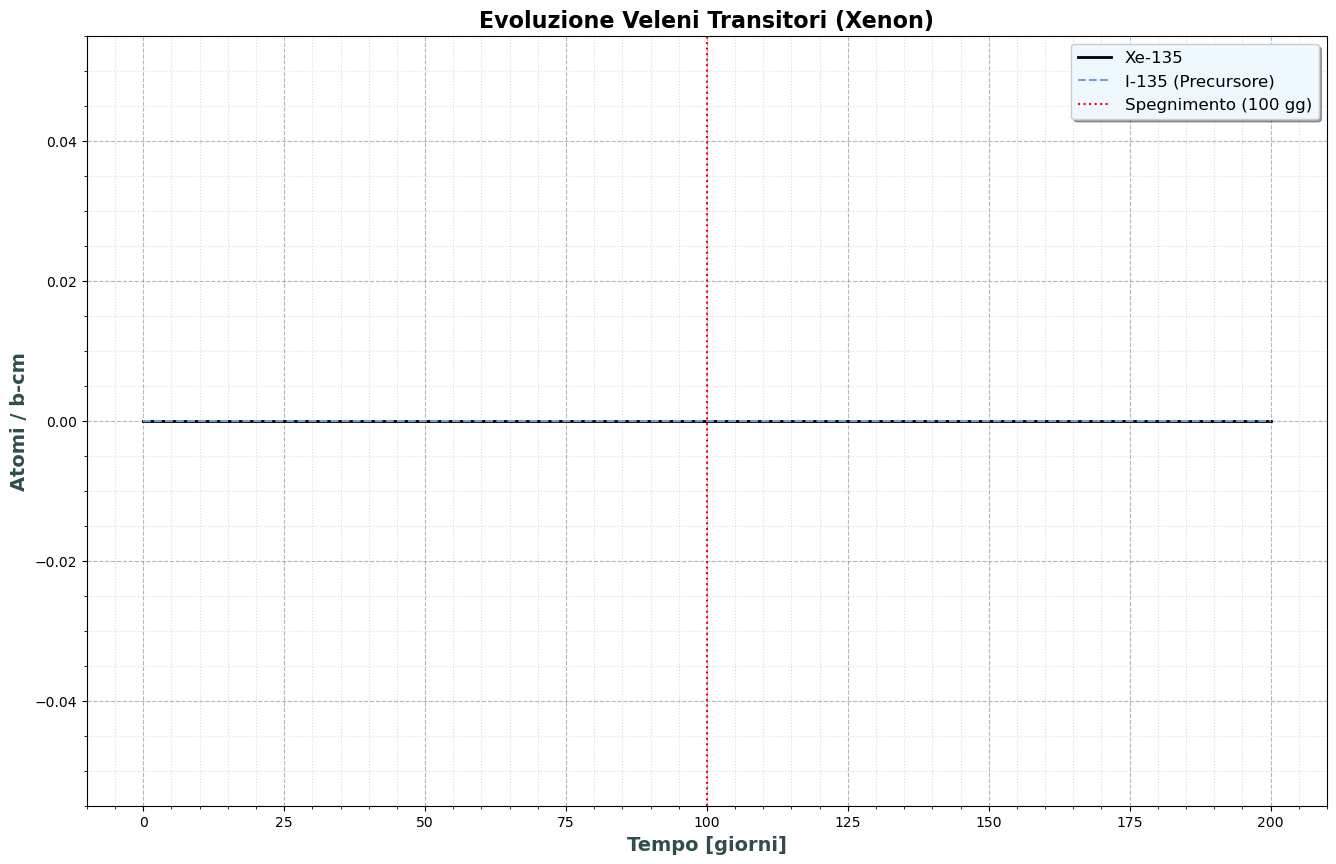

In [1]:
import openmc.deplete
import matplotlib.pyplot as plt

# 1. Caricamento dei risultati
results = openmc.deplete.Results("depletion_results.h5")

# 2. Estrazione del tempo (convertito in giorni) e delle densità atomiche
# Specifica il nome di un materiale depletable (es. 'fuel_ring_5' o 'mat_target')
material_id = "2" # Nota: controlla l'ID del materiale combustibile nel summary.h5 o usa il nome
time, xenon = results.get_atoms(material_id, "Xe135")
time, samarium = results.get_atoms(material_id, "Sm149")
time, iodine = results.get_atoms(material_id, "I135")

days = time / (24 * 3600)

# 3. Plotting in stile scientifico
plt.figure(figsize=(16, 10))
plt.plot(days, xenon, label="Xe-135", color='#000000', linewidth=2)
plt.plot(days, iodine, label="I-135 (Precursore)", color='#789DD1', linestyle='--')
plt.axvline(x=100, color='red', linestyle=':', label="Spegnimento (100 gg)")

plt.title("Evoluzione Veleni Transitori (Xenon)", fontsize=16, fontweight='bold')
plt.xlabel("Tempo [giorni]", fontsize=14, fontweight='bold', color='#2F4F4F')
plt.ylabel("Atomi / b-cm", fontsize=14, fontweight='bold', color='#2F4F4F')
plt.grid(True, which='major', linestyle='--', alpha=0.6, color='#778899')
plt.minorticks_on()
plt.grid(True, which='minor', linestyle=':', alpha=0.3, color='#778899')
plt.legend(loc='upper right', frameon=True, shadow=True, fontsize=12, facecolor='#F0F8FF')
plt.show()